In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1️⃣ Leer los 3 archivos
file_paths = {
    "EICH101": r"C:/Users/diana/OneDrive - Universidad de los Andes/Documentos/9no Semestre/TesisGEB_AlejaYCami/Repositorio/ProyectoGradoGEB/datos/EICH101.xlsx",
    "EICH102": r"C:/Users/diana/OneDrive - Universidad de los Andes/Documentos/9no Semestre/TesisGEB_AlejaYCami/Repositorio/ProyectoGradoGEB/datos/EICH102.xlsx",
    "EICH104": r"C:/Users/diana/OneDrive - Universidad de los Andes/Documentos/9no Semestre/TesisGEB_AlejaYCami/Repositorio/ProyectoGradoGEB/datos/EICH104.xlsx"
}

# Cargar los archivos en dataframes
e1 = pd.read_excel(file_paths["EICH101"])
e2 = pd.read_excel(file_paths["EICH102"])
e3 = pd.read_excel(file_paths["EICH104"])

# 2️⃣ Filtrar registros según ORIG_RAW_VOLUME
e1 = e1[e1["ORIG_RAW_VOLUME"] <= 60]
e2 = e2[e2["ORIG_RAW_VOLUME"] <= 120]
e3 = e3[e3["ORIG_RAW_VOLUME"] <= 350]

# 3️⃣ Convertir EFFECTIVE_DATE a formato de fecha
e1["EFFECTIVE_DATE"] = pd.to_datetime(e1["EFFECTIVE_DATE"], errors='coerce')
e2["EFFECTIVE_DATE"] = pd.to_datetime(e2["EFFECTIVE_DATE"], errors='coerce')
e3["EFFECTIVE_DATE"] = pd.to_datetime(e3["EFFECTIVE_DATE"], errors='coerce')

# Agregar columna de empresa e identificarla con One-Hot Encoding
e1["empresa"] = "EICH101"
e2["empresa"] = "EICH102"
e3["empresa"] = "EICH104"

# Unificar los tres DataFrames en uno solo
df = pd.concat([e1, e2, e3], ignore_index=True)

# Aplicar One-Hot Encoding a la columna "empresa"
df = pd.get_dummies(df, columns=["empresa"])

# 4️⃣ Eliminar registros con valores nulos, duplicados y negativos
df = df.dropna()  # Eliminar registros con valores nulos
df = df.drop_duplicates()  # Eliminar duplicados
# Seleccionar solo columnas numéricas antes de eliminar valores negativos
numeric_columns = df.select_dtypes(include=["number"]).columns
df = df[df[numeric_columns].ge(0).all(axis=1)]


# 5️⃣ Aplicar normalización a ORIG_RAW_VOLUME usando percentil 99
global_max = np.percentile(df["ORIG_RAW_VOLUME"], 99)
df["ORIG_RAW_VOLUME_NORM"] = df["ORIG_RAW_VOLUME"] / global_max
df["ORIG_RAW_VOLUME_NORM"] = np.clip(df["ORIG_RAW_VOLUME_NORM"], 0, 1)  # Asegurar que esté entre 0 y 1


In [ ]:
print(df.head())

   ORIG_STD_VOLUME  STD_VOLUME  ORIG_TEMPERATURE  TEMPERATURE   PRESSURE  \
0         0.000000    0.000000         23.304819    23.304819  17.686537   
1        17.516075   17.516081         23.449533    23.449533  17.705580   
2        19.025777   19.025784         23.625006    23.625006  17.690292   
3        14.820577   14.820582         23.636658    23.636658  17.708681   
4        14.184913   14.184918         23.636869    23.636869  17.692707   

   ORIG_PRESSURE  ORIG_RAW_VOLUME  RAW_VOLUME      EFFECTIVE_DATE  \
0      17.686537            0.000       0.000 2018-09-03 09:00:00   
1      17.705580           25.875      25.875 2018-09-03 10:00:00   
2      17.690292           28.125      28.125 2018-09-03 11:00:00   
3      17.708681           21.875      21.875 2018-09-03 12:00:00   
4      17.692707           21.000      21.000 2018-09-03 13:00:00   

   empresa_EICH101  empresa_EICH102  empresa_EICH104  ORIG_RAW_VOLUME_NORM  
0             True            False            Fals

In [ ]:
import os
import pandas as pd
import numpy as np
import pywt
import matplotlib.pyplot as plt
import math

# Crear la carpeta donde se guardarán las imágenes
output_folder = "C:/Users/diana/OneDrive - Universidad de los Andes/Documentos/9no Semestre/TesisGEB_AlejaYCami/Repositorio/ProyectoGradoGEB/modelos/escalogramas"
os.makedirs(output_folder, exist_ok=True)

# Escalas para la Transformada Wavelet Continua (CWT)
scales = np.arange(1, 128)

# Lista de empresas (columnas One-Hot Encoding)
empresas = ['empresa_EICH101', 'empresa_EICH102', 'empresa_EICH104']

# Recorrer el archivo secuencialmente
df_sorted = df.sort_values(by="EFFECTIVE_DATE")

for empresa in empresas:
    # Filtrar solo las filas donde la empresa tiene valor 1 en One-Hot Encoding
    df_empresa = df_sorted[df_sorted[empresa] == 1]

    # Obtener los años únicos en el DataFrame
    years = df_empresa['EFFECTIVE_DATE'].dt.year.unique()

    for year in years:
        df_year = df_empresa[df_empresa['EFFECTIVE_DATE'].dt.year == year]

        # Obtener las semanas únicas ordenadas
        weeks = sorted(df_year['EFFECTIVE_DATE'].dt.isocalendar().week.unique())

        for week in weeks:
            df_week = df_year[df_year['EFFECTIVE_DATE'].dt.isocalendar().week == week]

            if not df_week.empty:
                # Extraer la señal de la semana (manteniendo valores originales sin escalar)
                signal_week = df_week['ORIG_RAW_VOLUME_NORM'].values

                # Aplicar la Transformada Wavelet Continua (CWT) con Morlet
                coefficients, frequencies = pywt.cwt(signal_week, scales, 'morl')

                # Crear la figura del escalograma
                plt.figure(figsize=(10, 6))
                plt.imshow(np.abs(coefficients), aspect="auto", cmap="jet",
                           extent=[0, len(signal_week), scales[-1], scales[0]])
                plt.colorbar(label="Magnitud")
                plt.title(f"Escalograma - {empresa} - Año {year} - Semana {week}", fontsize=12, fontweight="bold")
                plt.xlabel("Horas de la Semana")
                plt.ylabel("Escala")

                # Guardar la imagen
                filename = f"{empresa}_Año{year}_Semana{week}.png".replace(" ", "_")
                filepath = os.path.join(output_folder, filename)
                plt.savefig(filepath, dpi=300, bbox_inches="tight")
                plt.close()

# Listar los archivos generados
generated_files = os.listdir(output_folder)
print("Ejemplo de archivos generados:", generated_files[:10])  # Mostrar solo los primeros 10 archivos como muestra

Ejemplo de archivos generados: ['empresa_EICH101_Año2018_Semana1.png', 'empresa_EICH101_Año2018_Semana36.png', 'empresa_EICH101_Año2018_Semana37.png', 'empresa_EICH101_Año2018_Semana38.png', 'empresa_EICH101_Año2018_Semana39.png', 'empresa_EICH101_Año2018_Semana40.png', 'empresa_EICH101_Año2018_Semana41.png', 'empresa_EICH101_Año2018_Semana42.png', 'empresa_EICH101_Año2018_Semana43.png', 'empresa_EICH101_Año2018_Semana44.png']


## CNN

#### Carga Imagenes Image Generator

In [2]:
import tensorflow as tf 
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Definir las rutas del dataset
dataset_path = "C:/Users/diana/OneDrive - Universidad de los Andes/Documentos/9no Semestre/TesisGEB_AlejaYCami/Repositorio/ProyectoGradoGEB/modelos"  # 📌 Reemplaza con la ruta real

# Generador de datos con aumentación para entrenar mejor
datagen = ImageDataGenerator(
    rescale=1./255,  # Normalizar los valores de los píxeles a [0,1]
    validation_split=0.2  # Usar 20% de las imágenes para validación
)

# Cargar las imágenes en lotes
batch_size = 32
img_size = (128, 128)  # Ajusta según la resolución de tus escalogramas

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",  # Clasificación binaria (normal vs anómalo)
    subset="training"
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation"
)


Found 669 images belonging to 2 classes.
Found 167 images belonging to 2 classes.


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# 🔹 Definir la arquitectura de la CNN
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),  # Reduce overfitting
    Dense(1, activation='sigmoid')  # Salida binaria (normal vs anómalo)
])

# 🔹 Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 🔹 Mostrar resumen del modelo
model.summary()

# Definir las rutas del dataset
dataset_path = "C:/Users/diana/OneDrive - Universidad de los Andes/Documentos/9no Semestre/TesisGEB_AlejaYCami/Repositorio/ProyectoGradoGEB/modelos"  # 📌 Reemplaza con la ruta real

# Generador de datos con aumentación para entrenar mejor
datagen = ImageDataGenerator(
    rescale=1./255,  # Normalizar los valores de los píxeles a [0,1]
    validation_split=0.2  # Usar 20% de las imágenes para validación
)

# Cargar las imágenes en lotes
batch_size = 32
img_size = (128, 128)  # Ajusta según la resolución de tus escalogramas

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",  # Clasificación binaria (normal vs anómalo)
    subset="training"
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation"
)

# 🔹 Calcular pesos de clases para balancear datos
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

# 🔹 Entrenar el modelo con class_weight
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    class_weight=class_weight_dict,
    verbose=1
)

# 🔹 Guardar el modelo después del entrenamiento
model.save("modelo_cnn_escalogramas.h5")


c:\Users\diana\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Found 669 images belonging to 2 classes.
Found 167 images belonging to 2 classes.


c:\Users\diana\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.6262 - loss: 0.6686 - val_accuracy: 0.8323 - val_loss: 0.4554
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.8542 - loss: 0.3919 - val_accuracy: 0.8263 - val_loss: 0.3910
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.9169 - loss: 0.2169 - val_accuracy: 0.8323 - val_loss: 0.3531
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.9167 - loss: 0.2502 - val_accuracy: 0.8383 - val_loss: 0.3298
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.9031 - loss: 0.2305 - val_accuracy: 0.8503 - val_loss: 0.3040
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.9165 - loss: 0.2184 - val_accuracy: 0.8263 - val_loss: 0.3393
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9309 - loss: 0.1827 - val_accuracy: 0.8204 - val_loss: 0.4783
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9339 - loss: 0.1825 - val_accuracy: 0.8563 - val_loss:

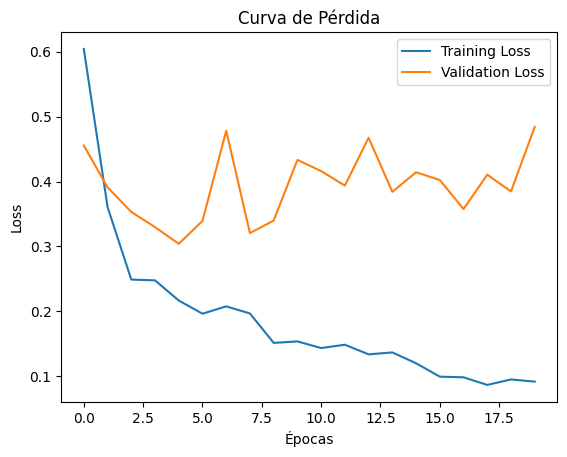

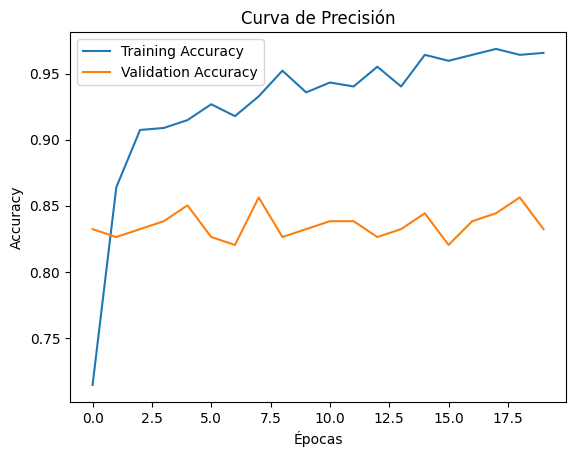

In [6]:
import matplotlib.pyplot as plt

# Graficar Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.title('Curva de Pérdida')
plt.show()

# Graficar Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Curva de Precisión')
plt.show()


In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# 🔹 Definir la arquitectura de la CNN con Dropout
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),
    Dropout(0.2),  # 🔹 Agregar Dropout después de la primera capa convolucional

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.3),  # 🔹 Agregar Dropout después de la segunda capa convolucional

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.4),  # 🔹 Agregar Dropout después de la tercera capa convolucional

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),  # 🔹 Agregar Dropout antes de la salida
    Dense(1, activation='sigmoid')  # Salida binaria (normal vs anómalo)
])

# 🔹 Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 🔹 Mostrar resumen del modelo
model.summary()

# Definir las rutas del dataset
dataset_path = "C:/Users/diana/OneDrive - Universidad de los Andes/Documentos/9no Semestre/TesisGEB_AlejaYCami/Repositorio/ProyectoGradoGEB/modelos"  # 📌 Reemplaza con la ruta real

# Generador de datos con aumentación para entrenar mejor
datagen = ImageDataGenerator(
    rescale=1./255,  # Normalizar los valores de los píxeles a [0,1]
    validation_split=0.2  # Usar 20% de las imágenes para validación
)

# Cargar las imágenes en lotes
batch_size = 32
img_size = (128, 128)  # Ajusta según la resolución de tus escalogramas

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",  # Clasificación binaria (normal vs anómalo)
    subset="training"
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation"
)

# 🔹 Calcular pesos de clases para balancear datos
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

# 🔹 Entrenar el modelo con class_weight y Dropout
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    class_weight=class_weight_dict,
    verbose=1
)

# 🔹 Guardar el modelo después del entrenamiento
model.save("modelo_cnn_dropout.h5")


c:\Users\diana\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Found 669 images belonging to 2 classes.
Found 167 images belonging to 2 classes.


c:\Users\diana\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.5691 - loss: 0.8165 - val_accuracy: 0.8084 - val_loss: 0.4776
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.7802 - loss: 0.4893 - val_accuracy: 0.8204 - val_loss: 0.4258
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.8225 - loss: 0.4148 - val_accuracy: 0.8204 - val_loss: 0.4061
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.8641 - loss: 0.3313 - val_accuracy: 0.8204 - val_loss: 0.4006
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.8963 - loss: 0.2838 - val_accuracy: 0.8263 - val_loss: 0.3714
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.9306 - loss: 0.2062 - val_accuracy: 0.8323 - val_loss: 0.3349
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9215 - loss: 0.1909 - val_accuracy: 0.7784 - val_loss: 0.3856
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9250 - loss: 0.2179 - val_accuracy: 0.8263 - val_loss:

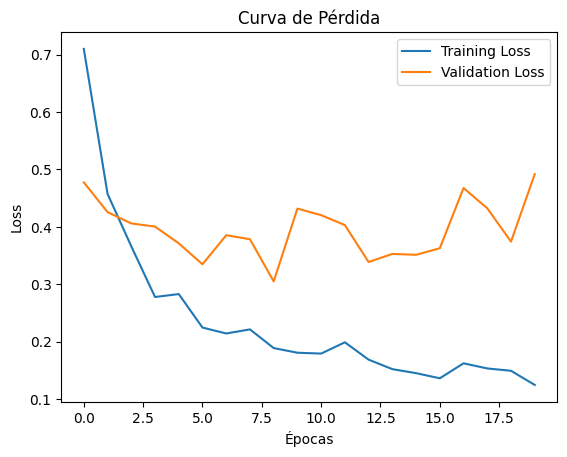

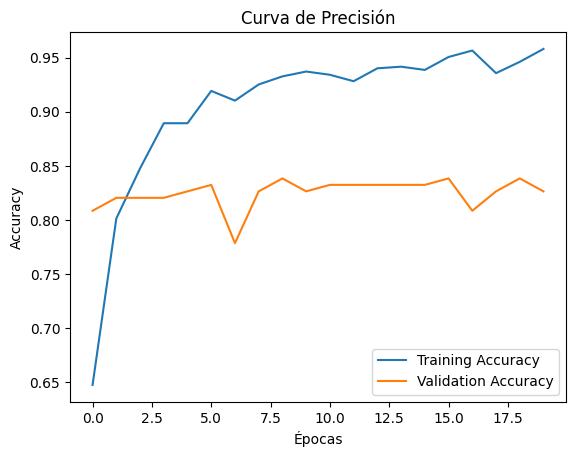

In [8]:
import matplotlib.pyplot as plt

# Graficar Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.title('Curva de Pérdida')
plt.show()

# Graficar Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Curva de Precisión')
plt.show()


In [1]:
# -*- coding: utf-8 -*-
"""
Created on Mon Feb 24 20:03:03 2025
"""

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# Parámetros
img_size = (224, 224)  # Tamaño de imagen compatible con MobileNetV2
batch_size = 32
epochs = 10
data_dir = r"C:/Users/diana/OneDrive - Universidad de los Andes/Documentos/9no Semestre/TesisGEB_AlejaYCami/Repositorio/ProyectoGradoGEB/modelos"  # 📌 Reemplaza con la ruta real
  # Carpeta principal

# Generador de datos con división en entrenamiento (80%) y validación (20%)
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Generadores para entrenamiento y validación
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="training"
)

test_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation"
)

# Cargar MobileNetV2 sin la capa de clasificación final
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")

# Congelar capas preentrenadas para que no se modifiquen
base_model.trainable = False

# Agregar nuevas capas de clasificación
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
outputs = Dense(1, activation="sigmoid")(x)  # Clasificación binaria

# Crear el modelo final
model = Model(inputs=base_model.input, outputs=outputs)

# Compilar el modelo
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Entrenar el modelo
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=epochs
)

# Evaluar el modelo
test_loss, test_acc = model.evaluate(test_generator)
print(f"Precisión en el conjunto de prueba: {test_acc * 100:.2f}%")

# Guardar el modelo entrenado
model.save("modelo_anomalias_MobileNetV2.h5")


Found 669 images belonging to 2 classes.
Found 167 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


c:\Users\diana\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 0.6741 - loss: 0.5980 - val_accuracy: 0.8204 - val_loss: 0.4498
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.9068 - loss: 0.2007 - val_accuracy: 0.8204 - val_loss: 0.5299
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.9256 - loss: 0.2046 - val_accuracy: 0.8383 - val_loss: 0.4336
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.9294 - loss: 0.1820 - val_accuracy: 0.8144 - val_loss: 0.6044
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9400 - loss: 0.1546 - val_accuracy: 0.8024 - val_loss: 0.3941
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.9433 - loss: 0.1562 - val_accuracy: 0.8383 - val_loss: 0.4215
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.9468 - loss: 0.1343 - val_accuracy: 0.8144 - val_loss: 0.3889
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9449 - loss: 0.1492 - val_accuracy: 0.8263 - val_loss:

Precisión en el conjunto de prueba: 85.03%


In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Mon Feb 24 19:01:31 2025
"""

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50, VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Flatten

# Parámetros
img_size = (224, 224)  # Tamaño de imagen compatible con los modelos
batch_size = 32
epochs = 10
data_dir = r"C:/Users/diana/OneDrive - Universidad de los Andes/Documentos/9no Semestre/TesisGEB_AlejaYCami/Repositorio/ProyectoGradoGEB/modelos"  # 📌 Reemplaza con la ruta real

# Generador de datos con división en entrenamiento (80%) y validación (20%)
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Generadores para entrenamiento y validación
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="training"
)

test_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation"
)

# Función corregida para construir modelos
def build_model(base_model):
    base_model.trainable = False  # Congelar capas preentrenadas
    
    # Asegurar que la entrada y salida están correctamente encadenadas
    inputs = base_model.input  # Obtener la entrada original del modelo base
    x = base_model.output  # Obtener la salida del modelo base
    
    # Aplicar GlobalAveragePooling2D para reducir dimensiones
    x = GlobalAveragePooling2D()(x) if "mobilenet" in base_model.name.lower() or "resnet" in base_model.name.lower() else Flatten()(x)
    
    # Agregar capas densas
    x = Dense(128, activation="relu")(x)
    outputs = Dense(1, activation="sigmoid")(x)  # Capa de salida para clasificación binaria
    
    # Crear el modelo final correctamente encadenado
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Definir los tres modelos
models = {
    "MobileNetV2": MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet"),
    "ResNet34": ResNet50(input_shape=(224, 224, 3), include_top=False, weights="imagenet"),  # ResNet50 se aproxima a ResNet34 en TF
    "VGG16bn": VGG16(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
}

# Entrenar y evaluar cada modelo
for name, base_model in models.items():
    print(f"\nEntrenando modelo: {name}")
    
    model = build_model(base_model)  # Crear el modelo

    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    
    history = model.fit(
        train_generator,
        validation_data=test_generator,
        epochs=epochs
    )

    test_loss, test_acc = model.evaluate(test_generator)
    print(f"Precisión de {name} en el conjunto de prueba: {test_acc * 100:.2f}%")

    # Guardar el modelo
    model.save(f"modelo_anomalias_{name}.h5")


Found 669 images belonging to 2 classes.
Found 167 images belonging to 2 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

Entrenando modelo: MobileNetV2
Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.6175 - loss: 0.6324 - val_accuracy: 0.8144 - val_loss: 0.4140
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.8999 - loss: 0.2283 - val_accuracy: 0.7784 - val_loss: 0.4293
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.9236 - loss: 0.1954 - val_accuracy: 0.8144 - val_loss: 0.5316
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.9138 - loss: 0.2427 - val_accuracy: 0.8144 - val_loss: 0.4143
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9137 - loss: 0.2143 - val_accuracy: 0.8204 - val_loss: 0.4632
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.9300 - loss: 0.1736 - val_accuracy: 0.8323 - val_loss: 0.4246
Epoch 7/10
21/21 ━━━━━━━━━━

Precisión de MobileNetV2 en el conjunto de prueba: 83.83%

Entrenando modelo: ResNet34
Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.5805 - loss: 0.6897 - val_accuracy: 0.5749 - val_loss: 0.6329
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 75s 4s/step - accuracy: 0.5891 - loss: 0.6478 - val_accuracy: 0.7066 - val_loss: 0.5723
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.7423 - loss: 0.5969 - val_accuracy: 0.6467 - val_loss: 0.5885
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 60s 3s/step - accuracy: 0.7174 - loss: 0.5798 - val_accuracy: 0.8204 - val_loss: 0.4957
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 74s 4s/step - accuracy: 0.7279 - loss: 0.5593 - val_accuracy: 0.7066 - val_loss: 0.5706
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 82s 4s/step - accuracy: 0.6770 - loss: 0.5574 - val_accuracy: 0.7784 - val_loss: 0.4851
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 75s 4s/step - accuracy: 0.7533 - loss: 0.5032 - val_accuracy: 0.8204 - val_loss: 0.4522
Epoch 8/10
21/21 ━━━━━━━━━━━━━━

Precisión de ResNet34 en el conjunto de prueba: 83.83%

Entrenando modelo: VGG16bn
Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 153s 7s/step - accuracy: 0.5568 - loss: 1.9486 - val_accuracy: 0.7904 - val_loss: 0.4497
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 99s 5s/step - accuracy: 0.8763 - loss: 0.3199 - val_accuracy: 0.8323 - val_loss: 0.4096
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 112s 5s/step - accuracy: 0.9155 - loss: 0.2285 - val_accuracy: 0.8323 - val_loss: 0.4231
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 113s 5s/step - accuracy: 0.9430 - loss: 0.1901 - val_accuracy: 0.8263 - val_loss: 0.4392
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 116s 6s/step - accuracy: 0.9443 - loss: 0.1739 - val_accuracy: 0.8204 - val_loss: 0.4534
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 114s 5s/step - accuracy: 0.9515 - loss: 0.1597 - val_accuracy: 0.8383 - val_loss: 0.4059
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 109s 5s/step - accuracy: 0.9558 - loss: 0.1621 - val_accuracy: 0.8383 - val_loss: 0.4192
Epoch 8/10
21/21 ━━━━━━━━━━━━

Precisión de VGG16bn en el conjunto de prueba: 83.83%
